In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPRegressor

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

# Load

In [535]:
path = "D:\\Research"

In [536]:
newness = np.load(f"{path}\\Creativity_Artnet\\Datasets\\newness_2024.npy",allow_pickle=True)
surprise = np.load(f"{path}\\Creativity_Artnet\\Datasets\\surprise_2024.npy",allow_pickle=True)
value = np.load(f"{path}\\Creativity_Artnet\\Datasets\\value_2024.npy",allow_pickle=True)

In [537]:
surprise = surprise.squeeze()

In [538]:
BASELINE_YEAR=1600

In [539]:
gold_set_70 = pd.read_excel(f"{path}\\Creativity_Artnet\\Codes\\Evaluation\\golden_set_move_creative_70.xlsx")
creative_70 = np.load(f"{path}\\Creativity_Artnet\\Datasets\\creativity_70_full_prob.npy",allow_pickle=True)
artnet_2024 = pd.read_excel(f"{path}\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")
merged_df = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [540]:
newness_df = np.zeros(merged_df.shape[0], dtype=object)
surprise_df = np.zeros(merged_df.shape[0], dtype=object)
value_df = np.zeros(merged_df.shape[0], dtype=object)
for i in range(merged_df.shape[0]):
    row_index = merged_df.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

The inverse of Sigmoid is Logit.

In [541]:
def logit(p, epsilon=1e-10):
    # Clip p to avoid log(0) or log(1/0)
    p = np.clip(p, epsilon, 1 - epsilon)
    return np.log(p / (1 - p))

In [542]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [543]:
def topk_hit_rate_curve(y_true, y_pred, rates):
    hit_rates = []
    n = len(y_true)

    for rate in rates:
        k = int(n * rate)
        if k == 0:
            hit_rates.append(np.nan)
            continue

        true_top_idx = np.argsort(y_true)[-k:]
        pred_top_idx = np.argsort(y_pred)[-k:]

        hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
        hit_rates.append(hit_rate)

    return hit_rates

In [544]:
def kl_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Normalize (important if they are not exact probabilities)
    p = p / p.sum()
    q = q / q.sum()

    # Avoid log(0)
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    return np.sum(p * np.log(p / q))

# Baseline

In [545]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.model_selection import KFold

In [546]:
epsilon=1e-6

In [547]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
#creativity_min = np.min(creative_70)
#creativity_max =np.max(creative_70)
#creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [523]:
creativity_normalized = creative_70

In [527]:
creative_70

array([0.7716005 , 0.9348798 , 0.94240716, ..., 0.94031968, 0.95915658,
       0.96766009], shape=(1874,))

In [528]:
y = logit(creativity_normalized,epsilon)
#y = np.log(creativity_normalized+epsilon)
y = creativity_normalized+epsilon
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

In [529]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=24)

In [530]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
mses=[]
maes=[]
rmses=[]
kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    true_label = sigmoid(y_test)
    pred_y = sigmoid(np.repeat(np.mean(y_train), len(y_test)))

    #true_label = np.exp(y_test)
    #pred_y = np.exp(np.repeat(np.mean(y_train), len(y_test)))

    #true_label = y_test
    #pred_y = np.repeat(np.mean(y_train), len(y_test))
    
    mse = mean_squared_error(true_label, np.array(pred_y))
    # print(f"Test Linear Regression model mse: {mse:.4f}")
    mae = mean_absolute_error(true_label, pred_y)
    # print("Test mae:", mae)
    rmse = root_mean_squared_error(true_label, pred_y)
    # print("Test RMSE:", RMSE)


    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    mses.append(mse)
    maes.append(mae)
    rmses.append(rmse)
    kls.append(kl)
    jss.append(js)
    wds.append(wd)
print(f"Average mse is {np.mean(mses)}, std is {np.std(mses)}")
print(f"Average mae is {np.mean(maes)}, std is {np.std(maes)}")
print(f"Average rmse is {np.mean(rmses)}, std is {np.std(rmses)}")
print("-------------------------------------------------------")
print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average mse is 5.681254979452107e-05, std is 8.677416448976061e-06
Average mae is 0.0052502481269252705, std is 0.00020948701580800457
Average rmse is 0.00751492767933098, std is 0.0005817316984196052
-------------------------------------------------------
Average KL is 5.492964984148697e-05, std is 8.483457101897406e-06
Average JS is 1.379275504161798e-05, std is 2.1419786812147458e-06
Average WD is 0.0052502481269252705, std is 0.0002094870158080051


In [531]:
sigmoid(np.mean(y_train))

np.float64(0.7206130087026528)

In [532]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )

Test Linear Regression model mse: 0.0001
Test mae: 0.005318276709890982
Test RMSE: 0.007921804411905983
Test KL: 6.062943515941109e-05
Test JS: 1.5243095963017334e-05
Test Wasserstein Distance : 0.005318276709890981


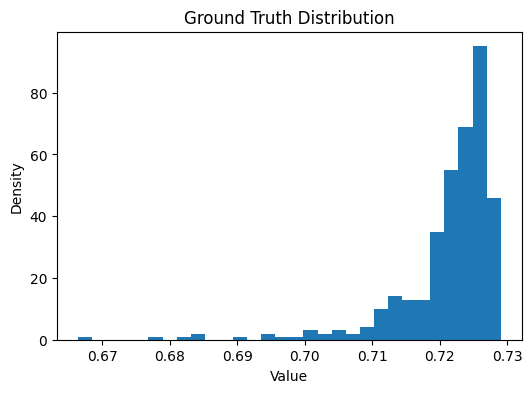

In [534]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(true_label, bins=30)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Ground Truth Distribution")
plt.show()

In [504]:
sum_error=0
for i in range(len(true_label)):
    a = true_label[i]
    b = pred_y[i]
    
    sum_error += abs(a-b)
    print(f"label is {a}, predicted label is {b}, error is {abs(a-b)}, sum is {sum_error}")

label is 0.6935056948604283, predicted label is 0.7023191467819879, error is 0.008813451921559579, sum is 0.008813451921559579
label is 0.7051146859259781, predicted label is 0.7023191467819879, error is 0.002795539143990222, sum is 0.0116089910655498
label is 0.7007640628198559, predicted label is 0.7023191467819879, error is 0.0015550839621319978, sum is 0.013164075027681799
label is 0.6239108686276152, predicted label is 0.7023191467819879, error is 0.07840827815437268, sum is 0.09157235318205448
label is 0.502935152947088, predicted label is 0.7023191467819879, error is 0.1993839938348999, sum is 0.2909563470169544
label is 0.7053821892911541, predicted label is 0.7023191467819879, error is 0.003063042509166225, sum is 0.2940193895261206
label is 0.6477349839683715, predicted label is 0.7023191467819879, error is 0.054584162813616444, sum is 0.34860355233973706
label is 0.7256823676789679, predicted label is 0.7023191467819879, error is 0.023363220896979953, sum is 0.37196677323671

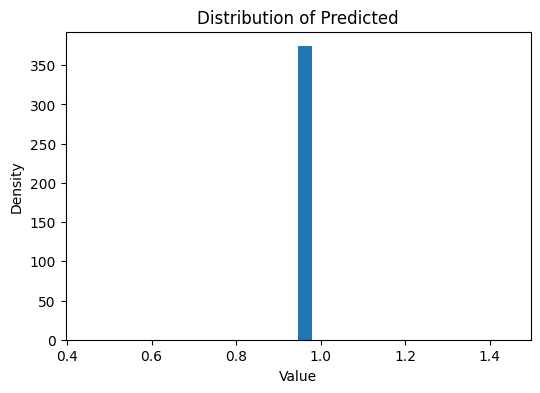

In [394]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pred_y, bins=30)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Distribution of Predicted")
plt.show()

# Basic

In [467]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.model_selection import cross_validate
from sklearn.metrics import recall_score
import sklearn
from sklearn import linear_model

In [473]:
epsilon=1e-6

In [474]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [475]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [476]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [477]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)
#creativity_normalized = 1-creative_70

In [478]:
#creativity_normalized = creative_70

In [479]:
#y = logit(creativity_normalized,epsilon)
#y = np.log(creativity_normalized+epsilon)
y = creativity_normalized+epsilon
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

In [362]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23)

In [480]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
mses=[]
maes=[]
rmses=[]
kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    
    # bins = np.quantile(y_train, np.linspace(0, 1,num=70 ))  # 10 quantile bins
    # # make bins strictly increasing (avoid duplicates if y has many ties)
    # bins = np.unique(bins)
    # bin_id = np.digitize(y_train, bins[1:-1], right=True)
    
    # counts = np.bincount(bin_id)
    # w = 1.0 / counts[bin_id]          # inverse frequency
    # w = w / np.mean(w)
    
    #model = LinearRegression()
    model = linear_model.GammaRegressor()
    #model.fit(X_train, y_train,sample_weight = w)
    model.fit(X_train, y_train)
    
    #true_label = np.exp(y_test)
    #pred = model.predict(X_test)
    #pred_y = np.exp(pred)
    
    #true_label = sigmoid(y_test)
    #pred = model.predict(X_test)
    #pred_y = sigmoid(pred)
    
    true_label = y_test
    pred = model.predict(X_test)
    pred_y = pred

    
    
    mse = mean_squared_error(true_label, np.array(pred_y))
    # print(f"Test Linear Regression model mse: {mse:.4f}")
    mae = mean_absolute_error(true_label, pred_y)
    # print("Test mae:", mae)
    rmse = root_mean_squared_error(true_label, pred_y)
    # print("Test RMSE:", RMSE)
    
    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )

    mses.append(mse)
    maes.append(mae)
    rmses.append(rmse)
    kls.append(kl)
    jss.append(js)
    wds.append(wd)

print(f"Average mse is {np.mean(mses)}, std is {np.std(mses)}")
print(f"Average mae is {np.mean(maes)}, std is {np.std(maes)}")
print(f"Average rmse is {np.mean(rmses)}, std is {np.std(rmses)}")

print("-------------------------------------------------------")

print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average mse is 0.014825297783564858, std is 0.0022230596116799704
Average mae is 0.0859071297055988, std is 0.003476831078797578
Average rmse is 0.12141105211081693, std is 0.009200772190928005
-------------------------------------------------------
Average KL is 0.011914314030987729, std is 0.0023047338551081408
Average JS is 0.003297238721575676, std is 0.0007176749257626538
Average WD is 0.08299837607195003, std is 0.002670627810134609


In [348]:
w

array([0.98619329, 1.01214575, 0.98619329, ..., 1.01214575, 1.01214575,
       1.01214575], shape=(1500,))

In [112]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [113]:
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [114]:
np.mean(pred_y)

np.float64(0.9561251208464303)

In [115]:
np.std(pred_y)

np.float64(0.000869890128814342)

In [78]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )

Test Linear Regression model mse: 0.0015
Test mae: 0.023734193968020074
Test RMSE: 0.038692889449614104
Test KL: 0.0008479736176853336
Test JS: 0.00021661523265137546
Test Wasserstein Distance : 0.02318927859739503


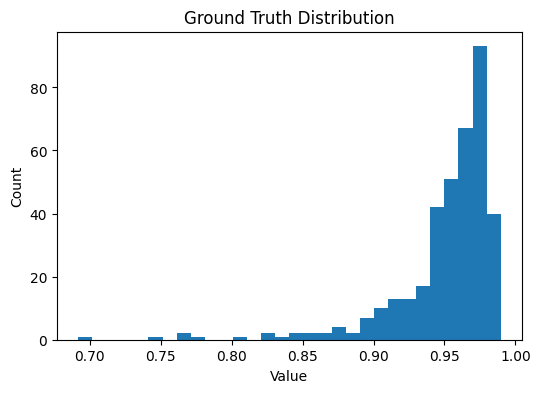

In [349]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(true_label, bins=30)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Ground Truth Distribution")
plt.show()

In [350]:
sum_error=0
for i in range(len(true_label)):
    a = true_label[i]
    b = pred_y[i]
    
    sum_error += abs(a-b)
    print(f"label is {a}, predicted label is {b}, error is {abs(a-b)}, sum is {sum_error}")

label is 0.934880798701453, predicted label is 0.9452628287939199, error is 0.010382030092466854, sum is 0.010382030092466854
label is 0.9515530096824055, predicted label is 0.9484613584693085, error is 0.0030916512130970686, sum is 0.013473681305563923
label is 0.9452617019874243, predicted label is 0.947954349783793, error is 0.0026926477963686857, sum is 0.01616632910193261
label is 0.8411593958871961, predicted label is 0.9458592663748243, error is 0.10469987048762819, sum is 0.1208661995895608
label is 0.6918590935157052, predicted label is 0.944373541244269, error is 0.2525144477285638, sum is 0.3733806473181246
label is 0.951941587120912, predicted label is 0.9469285107223175, error is 0.005013076398594496, sum is 0.3783937237167191
label is 0.8722358594166812, predicted label is 0.9465570379554564, error is 0.07432117853877518, sum is 0.45271490225549427
label is 0.9820664049386102, predicted label is 0.9463391428479689, error is 0.035727262090641254, sum is 0.4884421643461355


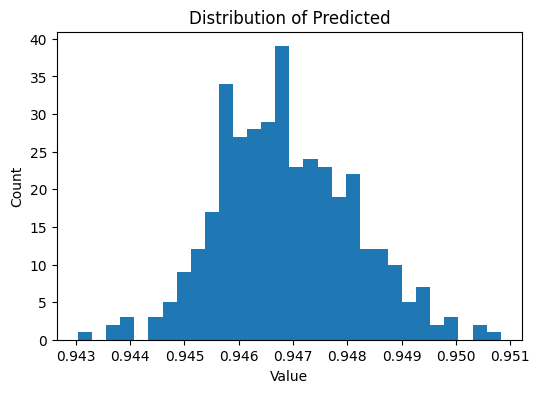

In [351]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pred_y, bins=30)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Distribution of Predicted")
plt.show()

In [53]:
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample", hit_rate)

Top 0.1 Hit Rate with 37 Sample 0.08108108108108109


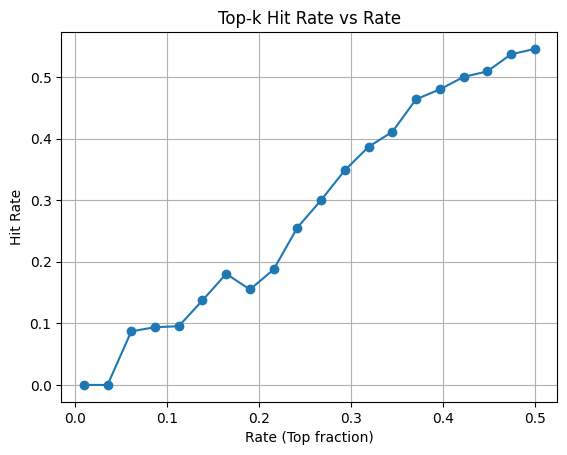

In [54]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(y_test, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

# Splines

In [260]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [261]:
y = logit(creativity_normalized,epsilon)
X = np.column_stack([
    np.log((newness_normalized+epsilon).astype(float)),
    np.log((surprise_normalized+epsilon).astype(float)),
    np.log((value_normalized+epsilon).astype(float))
])

In [262]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=24)

In [263]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=4,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [264]:
model = make_pipeline(
    preprocess,
    LinearRegression()
)

In [265]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [266]:
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [267]:
kf = KFold(n_splits=5,shuffle=True,random_state=24)
kf.get_n_splits()
mses=[]
maes=[]
rmses=[]
kls=[]
jss=[]
wds=[]
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train = X[train_index]
    X_test = X[test_index]
    y_train = y[train_index]
    y_test = y[test_index]

    model = make_pipeline(
        preprocess,
        LinearRegression()
    )
    model.fit(X_train, y_train)
    
    true_label = sigmoid(y_test)
    pred_y = sigmoid(model.predict(X_test))

    mse = mean_squared_error(true_label, np.array(pred_y))
    # print(f"Test Linear Regression model mse: {mse:.4f}")
    mae = mean_absolute_error(true_label, pred_y)
    # print("Test mae:", mae)
    rmse = root_mean_squared_error(true_label, pred_y)
    # print("Test RMSE:", RMSE)
    
    kl = kl_divergence(true_label, pred_y)
    # print("Test KL:", kl )
    js = jensenshannon(true_label, pred_y)**2
    # print("Test JS:", js )
    wd = wasserstein_distance(true_label, pred_y)
    # print("Test Wasserstein Distance :", wd )
    
    mses.append(mse)
    maes.append(mae)
    rmses.append(rmse)
    
    kls.append(kl)
    jss.append(js)
    wds.append(wd)

print(f"Average mse is {np.mean(mses)}, std is {np.std(mses)}")
print(f"Average mae is {np.mean(maes)}, std is {np.std(maes)}")
print(f"Average rmse is {np.mean(rmses)}, std is {np.std(rmses)}")

print("-------------------------------------------------------")

print(f"Average KL is {np.mean(kls)}, std is {np.std(kls)}")
print(f"Average JS is {np.mean(jss)}, std is {np.std(jss)}")
print(f"Average WD is {np.mean(wds)}, std is {np.std(wds)}")

Average mse is 0.01676813170152503, std is 0.0027974564527477293
Average mae is 0.08183824102554227, std is 0.00403515399422306
Average rmse is 0.1290213622712049, std is 0.011028135799287993
-------------------------------------------------------
Average KL is 0.024789956506101333, std is 0.023107360167522722
Average JS is 0.0036655666008677465, std is 0.0010217985817237137
Average WD is 0.07342285341489777, std is 0.003654566210169573


In [57]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample:", hit_rate)

Test Linear Regression model mse: 0.0173
Test mae: 0.08372938253405916
Test RMSE: 0.13145302226559402
Test KL: 0.013456305804180078
Test JS: 0.003745208114350608
Test Wasserstein Distance : 0.0767259261754435
Top 0.1 Hit Rate with 37 Sample: 0.10810810810810811


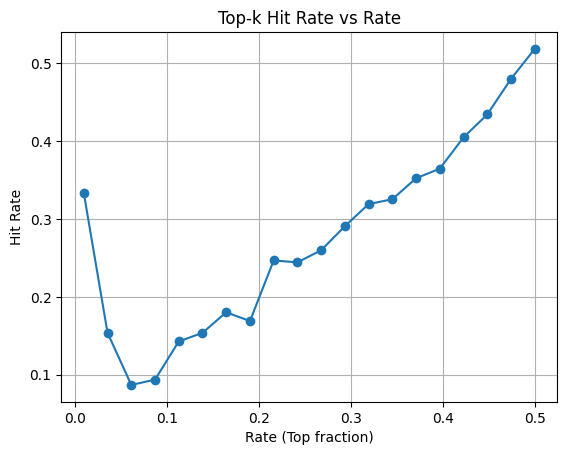

In [155]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(y_test, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

In [156]:
hit_rates

[0.3333333333333333,
 0.15384615384615385,
 0.08695652173913043,
 0.09375,
 0.14285714285714285,
 0.15384615384615385,
 0.18032786885245902,
 0.16901408450704225,
 0.24691358024691357,
 0.24444444444444444,
 0.26,
 0.2909090909090909,
 0.31932773109243695,
 0.32558139534883723,
 0.35251798561151076,
 0.36486486486486486,
 0.4050632911392405,
 0.43452380952380953,
 0.480225988700565,
 0.5187165775401069]

# Neural Network

In [58]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [59]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPRegressor(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=24)
        model.fit(X_train1, y_train1)

        
        true_label = sigmoid(y_val)
        pred_y = sigmoid(model.predict(X_val)) 

        mse = mean_squared_error(true_label, np.array(pred_y))
        #print(f"Test Linear Regression model mse: {mse:.4f}")
        mae = mean_absolute_error(true_label, pred_y)
        #print("Test mae:", mae)
        RMSE = root_mean_squared_error(true_label, pred_y)
        #print("Test RMSE:", RMSE)
        rho, pval = spearmanr(true_label, pred_y)
        #print("Test spearman:", rho)
        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = RMSE
        elif best_score < RMSE:
            best_alpha = alpha
            best_layer = layer
            best_score = RMSE
            
        
        result.append({'alpha':alpha,'layer':layer,'mse':mse,'mae':mae,'RMSE':RMSE,'spearman':rho})
        #print("Test F1:", f1)

In [60]:
model = MLPRegressor(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
model.fit(X_train, y_train)
true_label = sigmoid(y_test)
pred_y = sigmoid(model.predict(X_test))

In [62]:
mse = mean_squared_error(true_label, np.array(pred_y))
print(f"Test Linear Regression model mse: {mse:.4f}")
mae = mean_absolute_error(true_label, pred_y)
print("Test mae:", mae)
RMSE = root_mean_squared_error(true_label, pred_y)
print("Test RMSE:", RMSE)
kl = kl_divergence(true_label, pred_y)
print("Test KL:", kl )
js = jensenshannon(true_label, pred_y)**2
print("Test JS:", js )
wd = wasserstein_distance(true_label, pred_y)
print("Test Wasserstein Distance :", wd )
rate = 0.1
k = int(len(y_test) * rate)
true_top_idx = np.argsort(y_test)[-k:]
pred_top_idx = np.argsort(model.predict(X_test))[-k:]
hit_rate = len(set(true_top_idx) & set(pred_top_idx)) / k
print(f"Top {rate} Hit Rate with {k} Sample:", hit_rate)

Test Linear Regression model mse: 0.0173
Test mae: 0.0837757436536702
Test RMSE: 0.13159402343909232
Test KL: 0.01348608788602403
Test JS: 0.0037506160830923893
Test Wasserstein Distance : 0.07463605784261104
Top 0.1 Hit Rate with 37 Sample: 0.05405405405405406


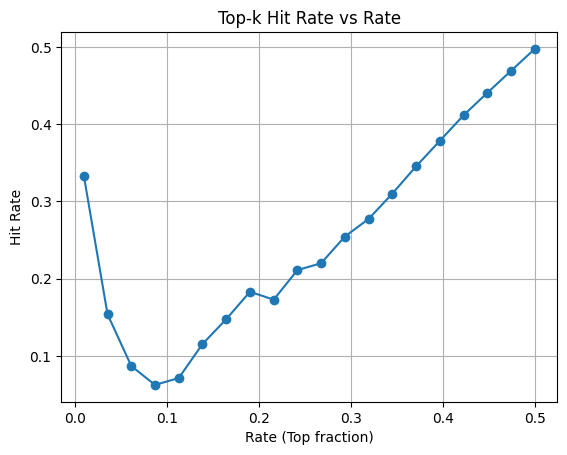

In [169]:
rates = np.linspace(0.01, 0.5, 20) 
hit_rates = topk_hit_rate_curve(true_label, pred_y, rates)
plt.figure()
plt.plot(rates, hit_rates, marker='o')
plt.xlabel("Rate (Top fraction)")
plt.ylabel("Hit Rate")
plt.title("Top-k Hit Rate vs Rate")
plt.grid(True)
plt.show()

In [170]:
hit_rates 

[0.3333333333333333,
 0.15384615384615385,
 0.08695652173913043,
 0.0625,
 0.07142857142857142,
 0.11538461538461539,
 0.14754098360655737,
 0.18309859154929578,
 0.1728395061728395,
 0.2111111111111111,
 0.22,
 0.2545454545454545,
 0.2773109243697479,
 0.31007751937984496,
 0.34532374100719426,
 0.3783783783783784,
 0.41139240506329117,
 0.44047619047619047,
 0.4689265536723164,
 0.49732620320855614]